#WEEK 1 -- TASK 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print("The libraries are loaded successfully")

The libraries are loaded successfully


In [ ]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
missing_summary

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## Data Story

- The training set contains **891 passengers across 12 columns**, covering demographics (Sex, Age), ticket details (Pclass, Fare, Ticket, Cabin), and family info (SibSp, Parch).
- Three columns have missing values: **Cabin** (~77% missing), **Age** (~20% missing), and **Embarked** (2 rows only) — Cabin is too sparse to impute reliably and is a better candidate for a binary "has_cabin" flag than direct imputation.
- The columns split into **7 numerical** (`PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare`) and **5 categorical** (`Name, Sex, Ticket, Cabin, Embarked`) — though `Survived` and `Pclass` behave more like labels than continuous numbers.
- The target `Survived` is imbalanced: roughly **62% did not survive** vs. **38% survived**, which matters for how any future model gets evaluated.
- `Fare` shows heavy right-skew with a few extreme outliers, which will need attention before scaling or modeling.
- Overall the dataset is small and mostly clean — Age and Cabin are the only real data-quality issues to solve before moving to feature engineering.

#WEEK 1 -- TASK 2

**Strategy, column by column:**
- **Age (~20% missing):** filled with the **median**. Age is right-skewed, so the median is a more robust "typical value" than the mean, which outliers would drag upward.
- **Embarked (2 missing):** filled with the **mode** (most frequent port). Only 2 rows are affected, so using the single most common category is low-risk and simple.
- **Cabin (~77% missing):** too sparse to impute meaningfully. Rather than guessing values for over three-quarters of a column, converted presence/absence into a new binary `Has_Cabin` column, then dropped the original `Cabin` column.

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Has_Cabin"] = df["Cabin"].notnull().astype(int)
df = df.drop(columns=["Cabin"])

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#BOXPLOT

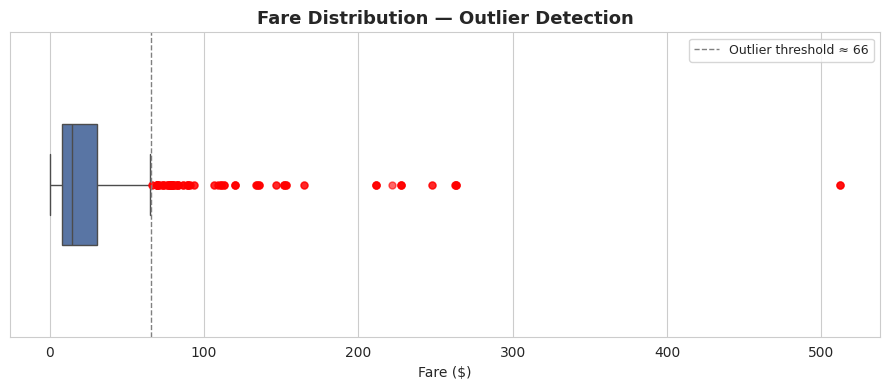

Passengers beyond the outlier threshold (Fare > 66): 116


In [ ]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(9, 4))

sns.boxplot(
    x=df["Fare"],
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    flierprops=dict(marker="o", markerfacecolor="red", markeredgecolor="red", alpha=0.6),
    ax=ax
)


q1, q3 = df["Fare"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr

ax.axvline(upper_whisker, color="gray", linestyle="--", linewidth=1,
           label=f"Outlier threshold ≈ {upper_whisker:.0f}")
ax.set_title("Fare Distribution — Outlier Detection", fontsize=13, fontweight="bold")
ax.set_xlabel("Fare ($)")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

n_outliers = (df["Fare"] > upper_whisker).sum()
print(f"Passengers beyond the outlier threshold (Fare > {upper_whisker:.0f}): {n_outliers}")

#HISTOGRAM

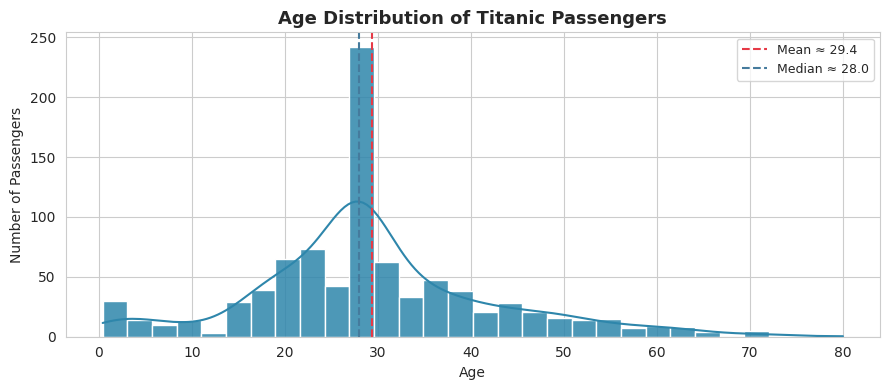

In [ ]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(df["Age"], bins=30, kde=True, color="#2E86AB", edgecolor="white", alpha=0.85, ax=ax)

mean_age = df["Age"].mean()
median_age = df["Age"].median()
ax.axvline(mean_age, color="#E63946", linestyle="--", linewidth=1.5, label=f"Mean ≈ {mean_age:.1f}")
ax.axvline(median_age, color="#457B9D", linestyle="--", linewidth=1.5, label=f"Median ≈ {median_age:.1f}")

ax.set_title("Age Distribution of Titanic Passengers", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Passengers")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

#BAR-CHART

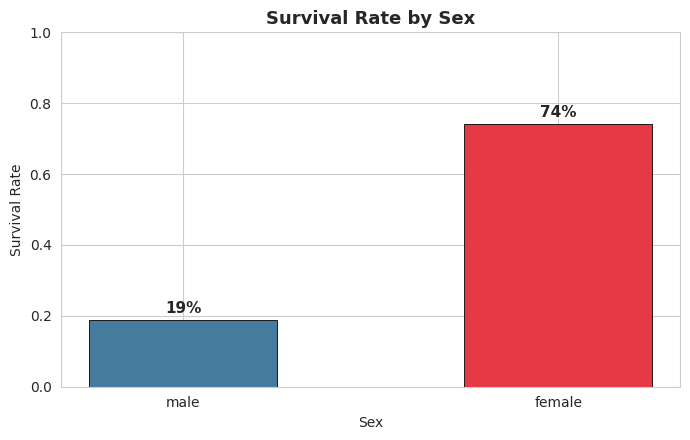

In [ ]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 4.5))

survival_by_sex = df.groupby("Sex")["Survived"].mean().reindex(["male", "female"])

bars = ax.bar(survival_by_sex.index, survival_by_sex.values,
              color=["#457B9D", "#E63946"], width=0.5, edgecolor="black", linewidth=0.6)

for bar, value in zip(bars, survival_by_sex.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.0%}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Survival Rate by Sex", fontsize=13, fontweight="bold")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Sex")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

#CORRELATION MAP

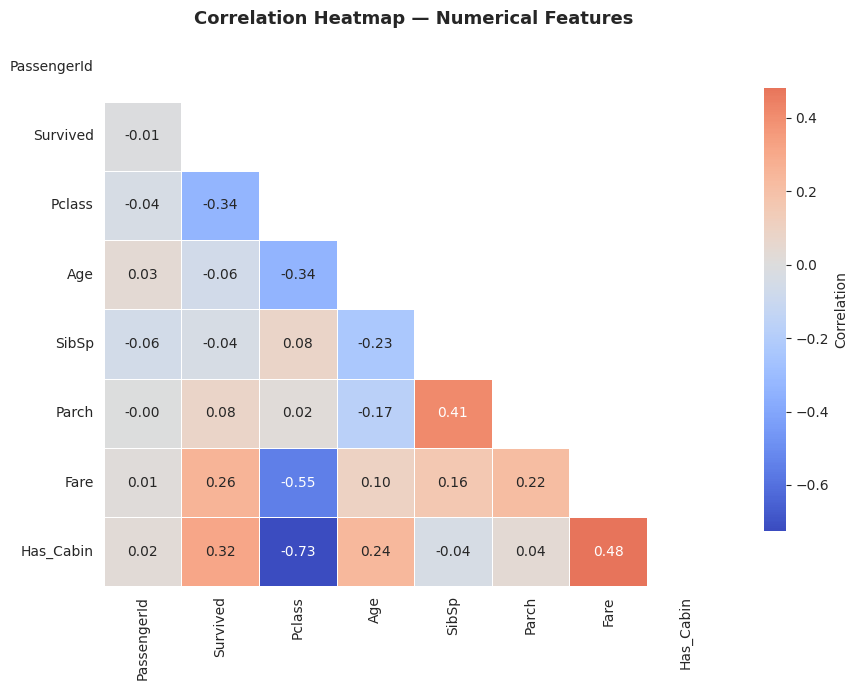

In [ ]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(9, 7))

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    ax=ax
)

ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#Which feature do you think most affects survival, and why?



**Answer:** **Sex** is the strongest single predictor of survival in this dataset. The bar chart shows a large gap between women's and men's survival rates — roughly 74% vs. 19% — bigger than the gap for any other feature. The correlation heatmap backs this up indirectly: `Pclass` and `Fare` also correlate with `Survived` (higher class / higher fare → better odds), which lines up with the historical "women and children first, and first class had better lifeboat access" account of the disaster. Correlation isn't causation, but the size and consistency of the Sex gap makes it the most convincing single explanation among the columns available.